# ANN REGRESION

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT->temperature
# V -> Vaccum
# AP -> pressure
# Rh -> humidity

# PE -> produce energy # we have to predict this
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE" , axis=1)
y = df["PE"]
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [6]:
# split our data
from sklearn.model_selection import train_test_split

X_train , X_test, y_train, y_test = train_test_split(
    X,y , test_size = 0.2 , random_state = 42
)
df.shape

(9568, 5)

In [7]:
#Scaling our data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [9]:
# Start converting our data into tensors
# pytorch easily handles for differentiantions and all if we already have tensors
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled , dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32).view(-1,1) # cause this is not in numpy form as it is not scaled , it is still in pandas format
# and we use the view(row , col) for stating the row and col ( if val = -1 it means detect on your own)

X_test_tensor = torch.tensor(X_test_scaled , dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32).view(-1,1) # same as above as it was not 

In [10]:
type(X_train_scaled)

numpy.ndarray

In [11]:
type(y_train)

pandas.core.series.Series

In [12]:
# so now we will have 2 inner layers 
from torch.utils.data import TensorDataset, DataLoader

# train_dataset = TensorDataset(input_feature , output_feature)
train_dataset = TensorDataset(X_train_tensor , y_train_tensor)
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)



In [13]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle = True)# suffle cause we dont want the initila to be the first batch and so on
test_loader = DataLoader(test_dataset,batch_size=32) # does not matter cause we have to use it for testing only



# Building the ANN Model( as dataset is ready) , DeepLearing Part starts

In [14]:
# Define our ANN model
class ANN(nn.Module):
    def __init__(self) : # defining constructore and its work is to call the super constructor
        super(ANN, self).__init__() # super constructor called

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6) , # cause 6 no of output from that layer
            nn.ReLU(),
    
            #2nd hidden Layer
            nn.Linear(6,6) , # cause 6 no of output from this layer also layer
            nn.ReLU(),
    
            #output layer
            nn.Linear(6,1) , # from 6 input to 1 output , in regression we use linear Acti. Fxn. in output layer
        )

    def forward(self , x): # as what we did above it self is the FORWARD PROPAGATION (so we just call it here)
        return self.model(x)

In [15]:
# now we will create an object for the model of the class ANN
import torch.optim as optim

model = ANN()

#loss , optimiser
crietrion = nn.MSELoss() # creterion on the basis of which we will optimise our model
optimizer = optim.Adam(model.parameters())

# so till now we have defined the architecture but still the learning is to be done ,
# weights and all that are still initialised to 0


# Training the ANN model now

In [16]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf") # init with infinity , cause after this any loss comes will have less loss only than this

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval() # whenever we are evaluating, we take to evaluation mode 🌟
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss: # checking is curr validation loss < best validation loss
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth , in this we store the best parameters of the model where it acts the best
        

epoch 1/100 ==> train loss = 204884.5328125 & val loss = 202095.90625
epoch 2/100 ==> train loss = 192542.42024739584 & val loss = 175835.171875
epoch 3/100 ==> train loss = 146399.4068033854 & val loss = 112709.375
epoch 4/100 ==> train loss = 79563.91396484376 & val loss = 51526.28515625
epoch 5/100 ==> train loss = 36454.48137207031 & val loss = 27032.3671875
epoch 6/100 ==> train loss = 23693.956319173176 & val loss = 21122.478515625
epoch 7/100 ==> train loss = 19511.085205078125 & val loss = 17489.19140625
epoch 8/100 ==> train loss = 15924.911201985677 & val loss = 13978.8349609375
epoch 9/100 ==> train loss = 12459.75381673177 & val loss = 10519.3095703125
epoch 10/100 ==> train loss = 9015.640514119466 & val loss = 7273.39306640625
epoch 11/100 ==> train loss = 6106.1096995035805 & val loss = 4741.85791015625
epoch 12/100 ==> train loss = 3958.6937321980795 & val loss = 2995.89306640625
epoch 13/100 ==> train loss = 2469.0955917358397 & val loss = 1839.170166015625
epoch 14/10

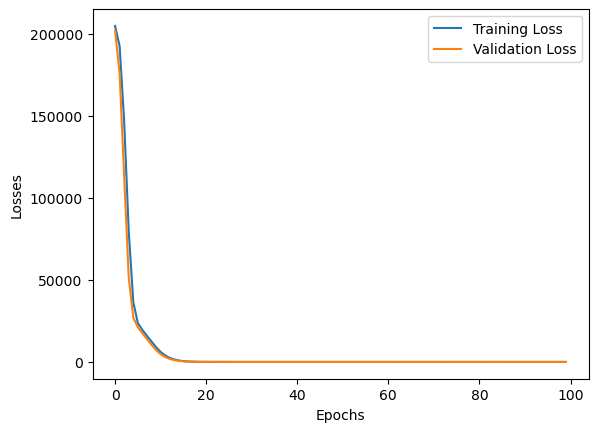

In [17]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validtion Loss"  : val_losses                 
})

plt.plot(loss_df["Training Loss"] , label = "Training Loss")
plt.plot(loss_df["Validtion Loss"] , label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

# Loading best Model

In [18]:
model.load_state_dict(torch.load("best_model.pt")) # we dont just have to load the parameter , we need to fit them in the architecture


<All keys matched successfully>

In [21]:
# Evaluate our model

model.eval()
with torch.no_grad():
    train_preds =model(X_train_tensor)
    test_preds =model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE : ", train_mse_loss.item())
print("Testing MSE : " , test_mse_loss.item())    

Training MSE :  20.417024612426758
Testing MSE :  18.819807052612305


In [22]:
from sklearn.metrics import r2_score

print("r^2 score =",r2_score(y_test , test_preds))


r^2 score = 0.9342296373874633


In [25]:
predicted_df = pd.DataFrame(test_preds.numpy() , columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values , columns=["Actual Values"])

pd.concat([predicted_df  , actual_df] , axis = 1)

,Predicted Values,Actual Values
0,435.251465,433.27
1,437.195099,438.16
2,461.428589,458.42
3,476.610168,480.82
4,435.298889,441.41
...,...,...
1909,451.572449,456.70
1910,431.734100,438.04
1911,467.796448,467.80
1912,431.210663,437.14
